## Visualize Computational Graph

**we are using graphviz Open Source Library to visualize arithmetic operations and their results in a beautiful way**

In [1]:
class Value:
    def __init__(self,data,_children=(),op='',label='',grad = 0.0):
        self.data = data
        self._op = op
        self._prev = set(_children)
        self.label = label
        self.grad = grad
        
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),op='+')
        return out

    def __mul__(self,other):
        out = Value(self.data * other.data,(self,other),op='*')
        return out
a = Value(2.0,label="a")
b = Value(-3.0,label="b")
c = a*b; c.label = 'c'
e = Value(10.0,label='e')
d = c + e;d.label = 'd'
f = Value(-2.0,label='f')
L = d*f; L.label= "L"
L

Value(data=-8.0)

In [2]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

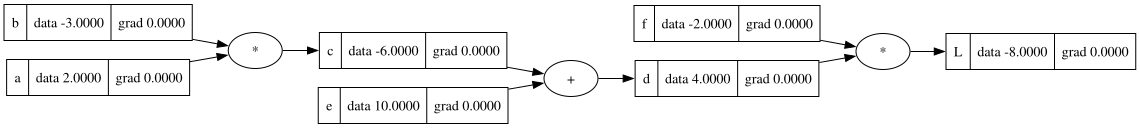

In [3]:
draw_dot(L)